# Data Gen 7: Heterogeneous Sigmoid Simulation via STD Scaling

Continuation of `data_gen6` with a new approach:

- Goal: analyze how ERP image morphology changes when the standard deviation of normally distributed input parameters is increased relative to the mean.
- Classes: `sigmoid` vs `no_class`.
- Three experiments:
  1. `σ = 50% of |μ|`
  2. `σ = 100% of |μ|`
  3. `σ = 1000% of |μ|` (10x mean)
- Each experiment simulates 4 instances and creates its own plot.


  Activating project at `~/Dokumente/BA2/notebooks/data_generation`
    Updating registry at `~/.julia/registries/General.toml`


UnfoldSim version 0.5.0 verified.

=== Full parameter settings | σ = 50% of |μ| ===
[SimulationConfig]
  mu_dist = Truncated(Normal{Float64}(μ=4.2, σ=2.1); lower=0.2, upper=12.0) | mean=4.339687 std=1.954857
  sigma_dist = Truncated(Normal{Float64}(μ=0.5, σ=0.25); lower=0.01, upper=3.0) | mean=0.514985 std=0.234378
  epoch_duration_dist = FixedDist(value=1.0) | mean=1.0 std=0.0
  sampling_rate_dist = FixedDist(value=512.0) | mean=512.0 std=0.0
  n_trials_dist = FixedDist(value=2508.0) | mean=2508.0 std=0.0
[ComponentConfig]
  p100_width_dist = Truncated(Normal{Float64}(μ=0.1, σ=0.05); lower=0.002, upper=0.6) | mean=0.102997 std=0.046876
  p100_window_offset_dist = Truncated(Normal{Float64}(μ=0.1, σ=0.05); lower=0.005, upper=1.2) | mean=0.103378 std=0.046559
  p100_n170_gap_dist = Truncated(Normal{Float64}(μ=0.07, σ=0.035); lower=0.002, upper=1.2) | mean=0.072172 std=0.032751
  n170_p300_gap_dist = Truncated(Normal{Float64}(μ=0.13, σ=0.065); lower=0.002, upper=1.2) | mean=0.133824 std=0

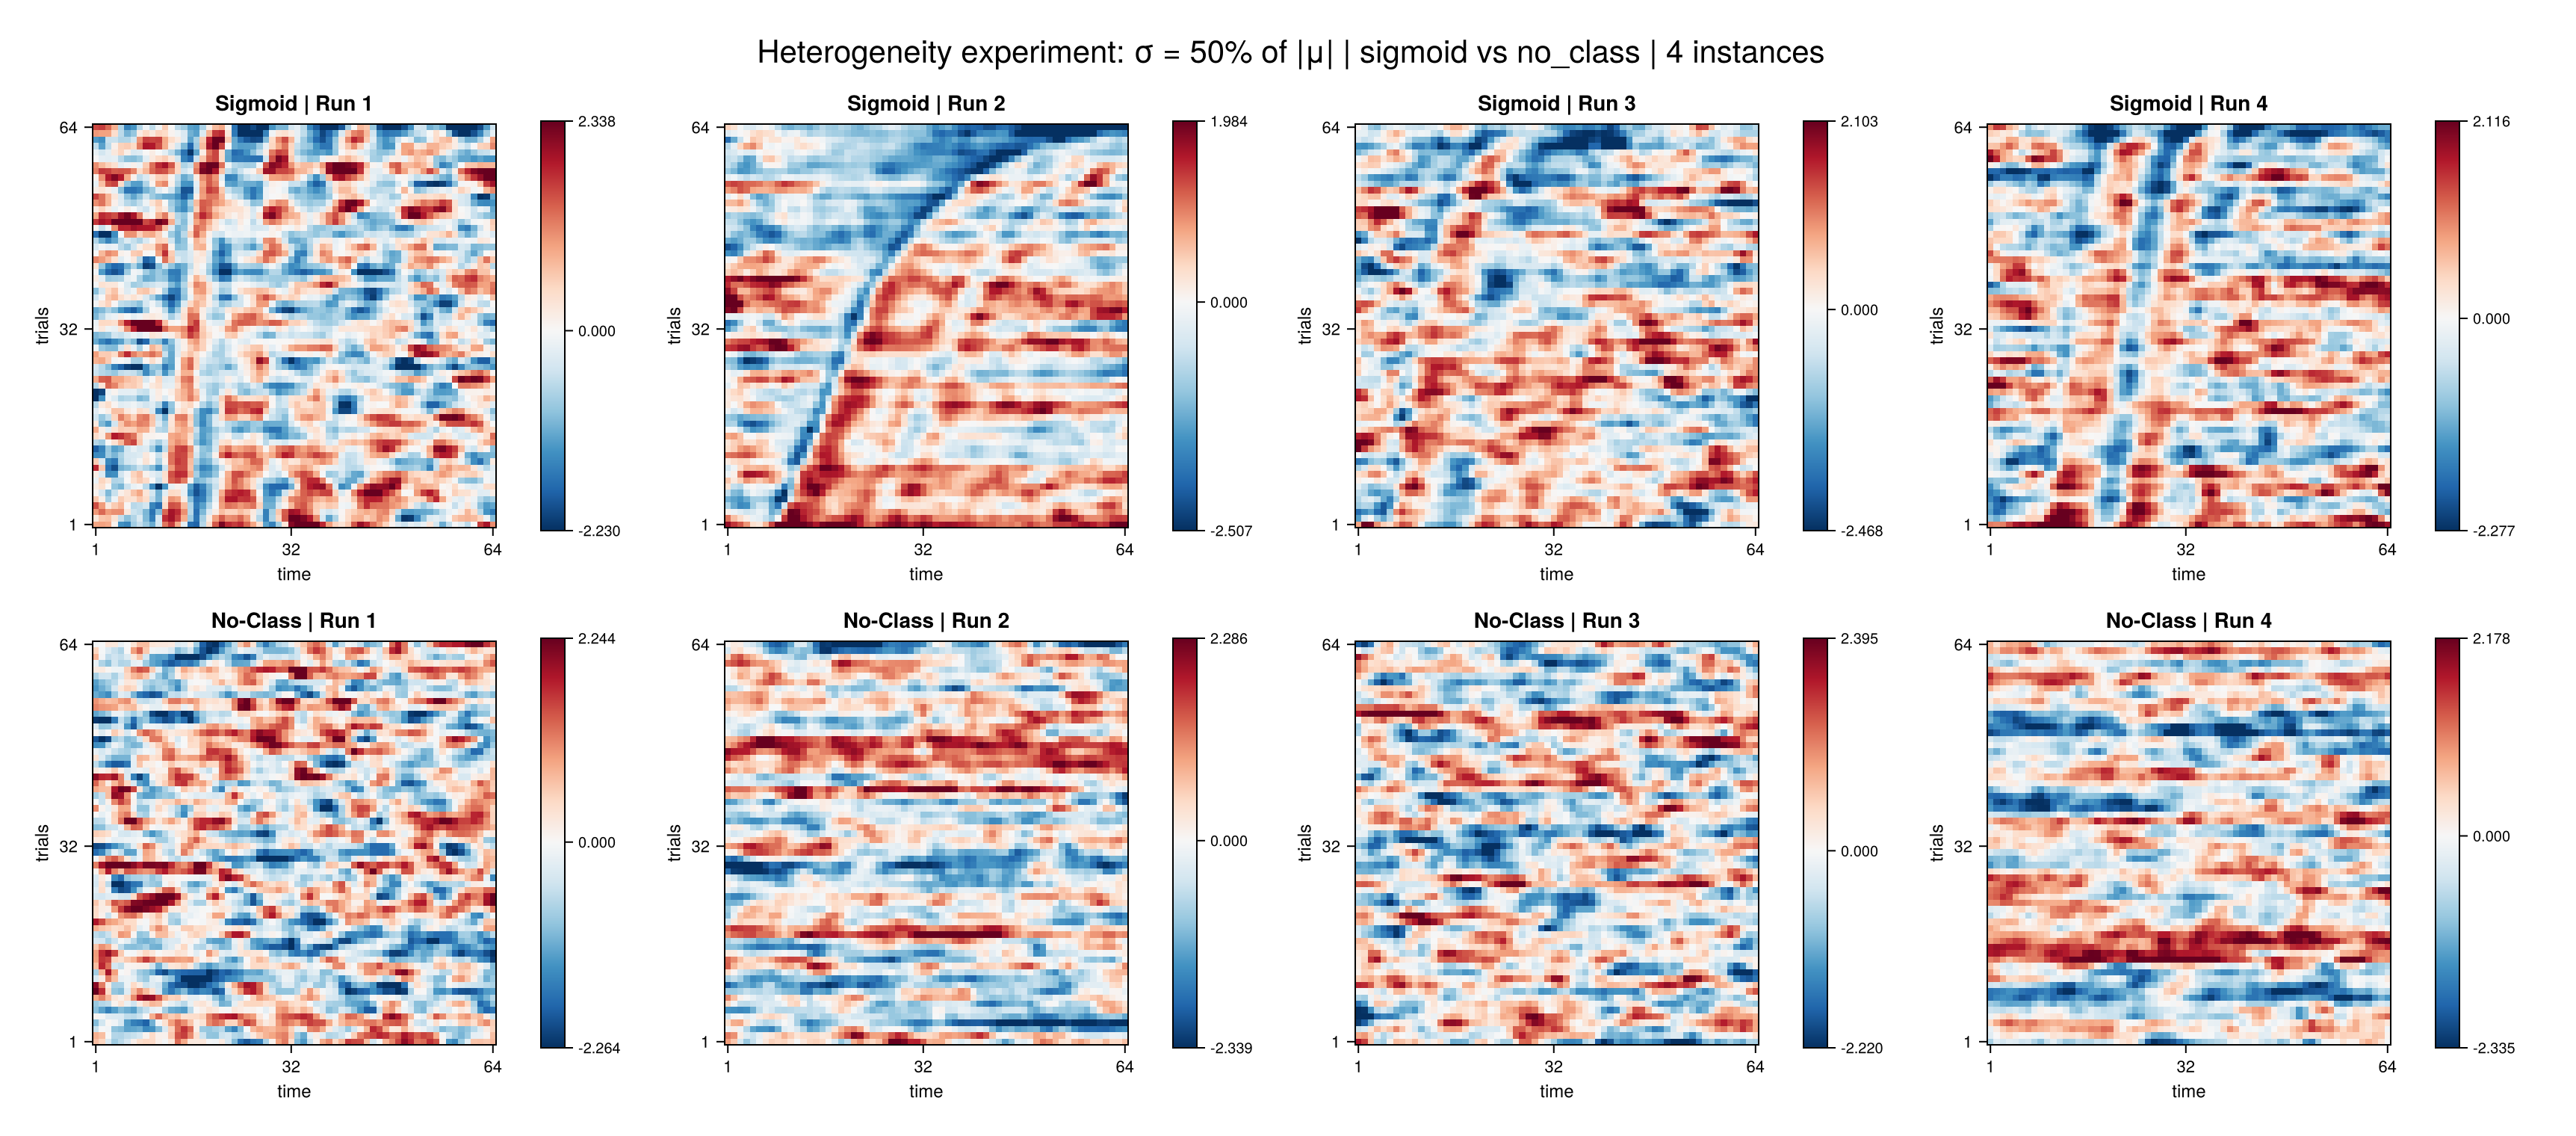


=== Full parameter settings | σ = 100% of |μ| ===
[SimulationConfig]
  mu_dist = Truncated(Normal{Float64}(μ=4.2, σ=4.2); lower=0.2, upper=12.0) | mean=5.159945 std=2.908856
  sigma_dist = Truncated(Normal{Float64}(μ=0.5, σ=0.5); lower=0.01, upper=3.0) | mean=0.647532 std=0.394894
  epoch_duration_dist = FixedDist(value=1.0) | mean=1.0 std=0.0
  sampling_rate_dist = FixedDist(value=512.0) | mean=512.0 std=0.0
  n_trials_dist = FixedDist(value=2508.0) | mean=2508.0 std=0.0
[ComponentConfig]
  p100_width_dist = Truncated(Normal{Float64}(μ=0.1, σ=0.1); lower=0.002, upper=0.6) | mean=0.129506 std=0.078979
  p100_window_offset_dist = Truncated(Normal{Float64}(μ=0.1, σ=0.1); lower=0.005, upper=1.2) | mean=0.130649 std=0.078416
  p100_n170_gap_dist = Truncated(Normal{Float64}(μ=0.07, σ=0.07); lower=0.002, upper=1.2) | mean=0.090881 std=0.055173
  n170_p300_gap_dist = Truncated(Normal{Float64}(μ=0.13, σ=0.13); lower=0.002, upper=1.2) | mean=0.168133 std=0.102785
  p300_width_dist = Truncated(

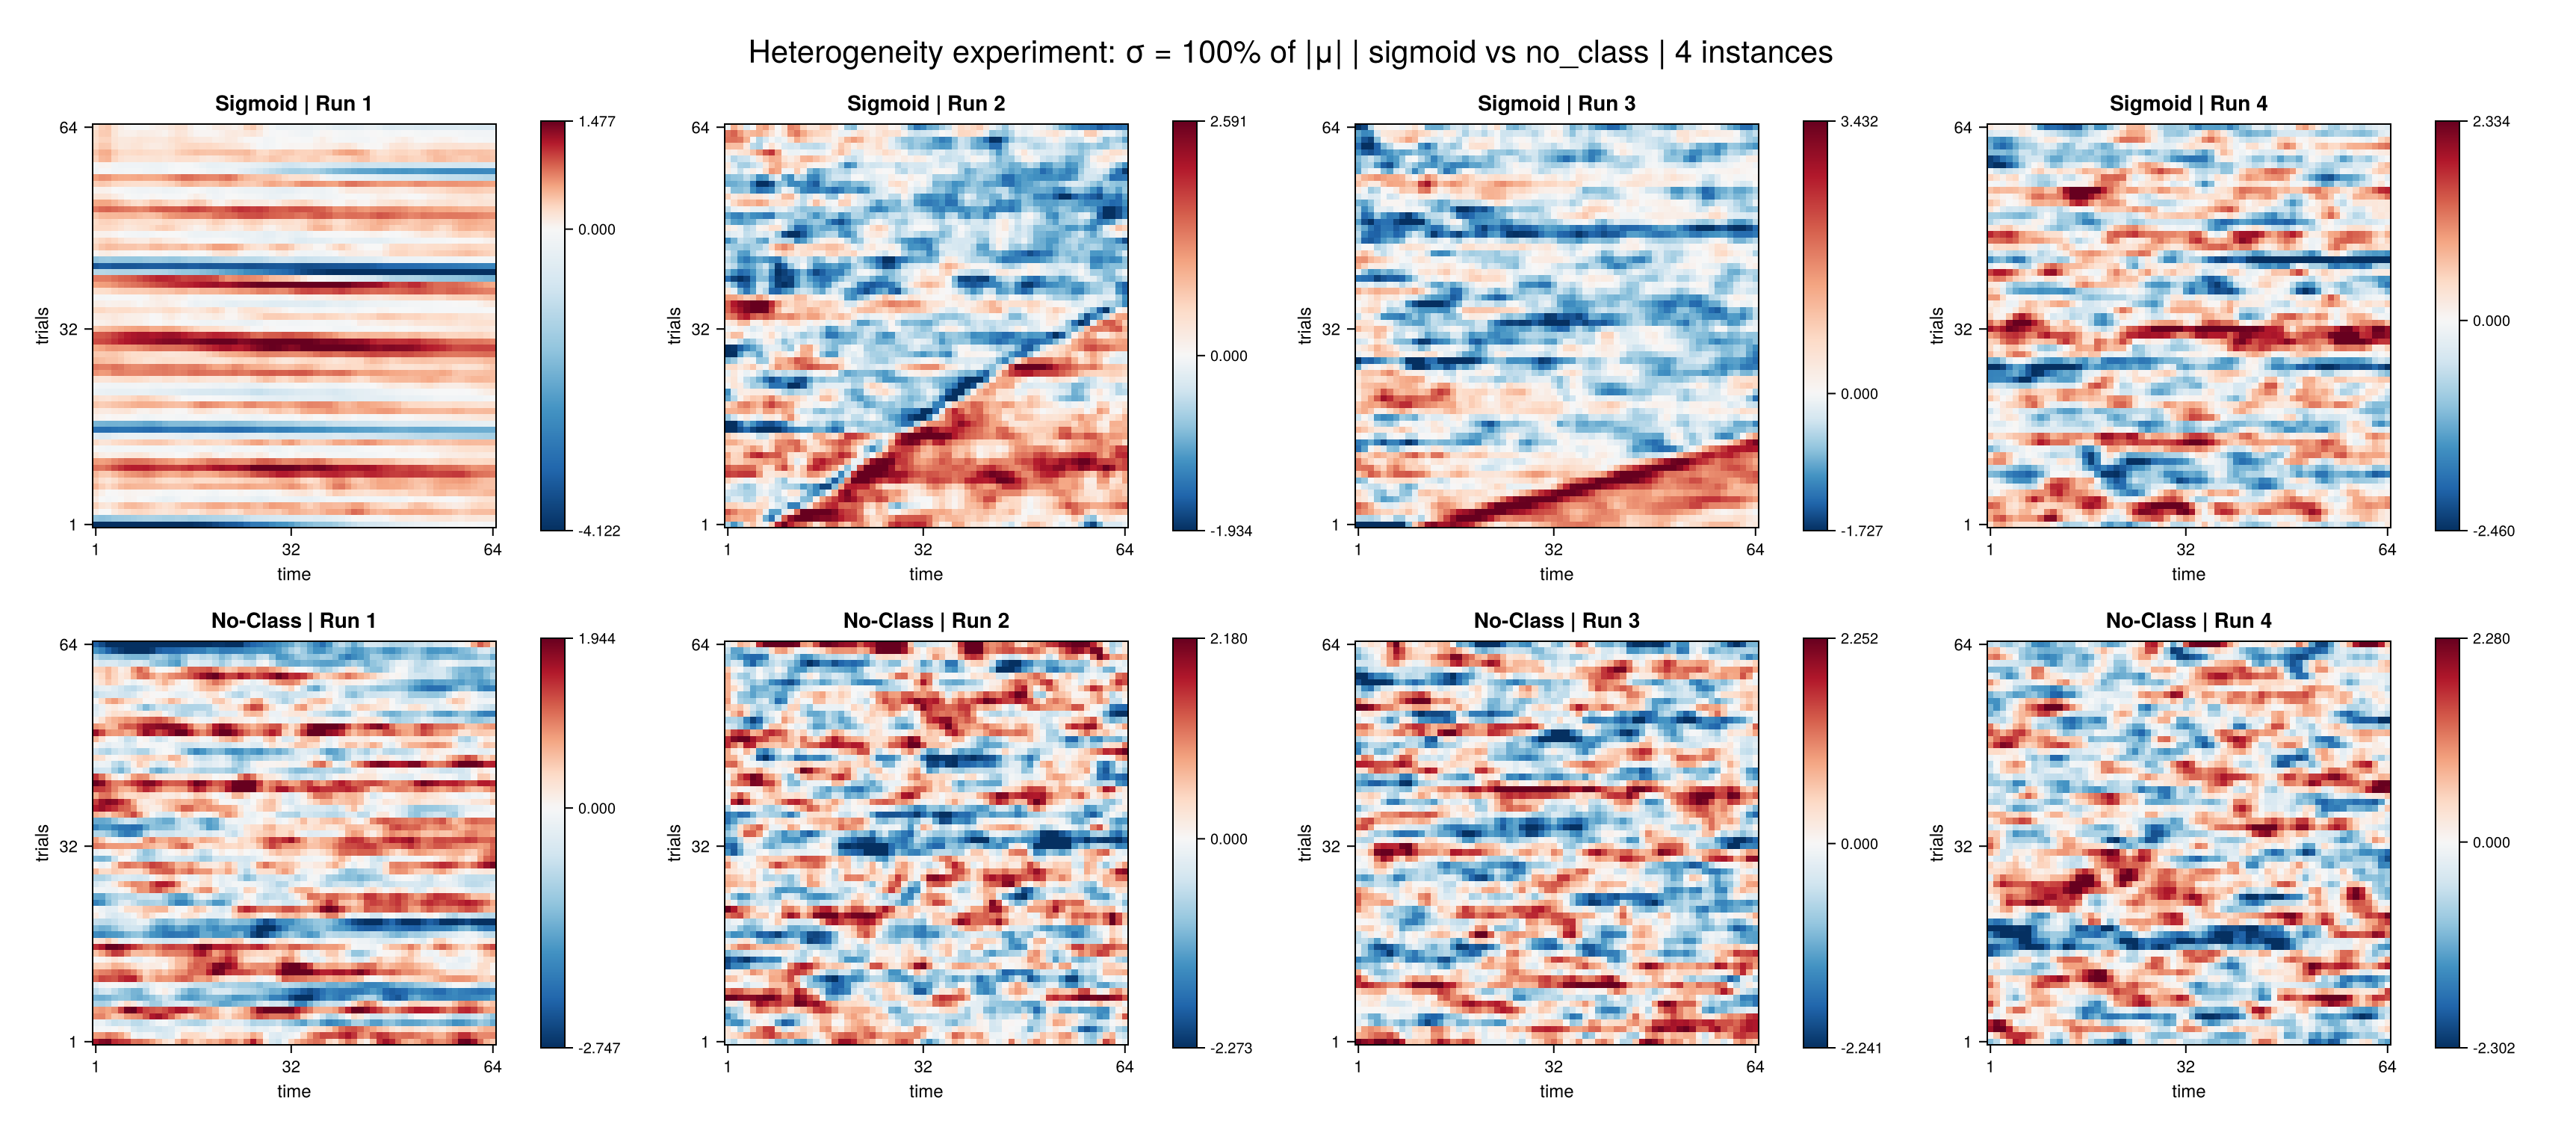


=== Full parameter settings | σ = 1000% of |μ| ===
[SimulationConfig]
  mu_dist = Truncated(Normal{Float64}(μ=4.2, σ=42.0); lower=0.2, upper=12.0) | mean=6.087535 std=3.401873
  sigma_dist = Truncated(Normal{Float64}(μ=0.5, σ=5.0); lower=0.01, upper=3.0) | mean=1.475413 std=0.857698
  epoch_duration_dist = FixedDist(value=1.0) | mean=1.0 std=0.0
  sampling_rate_dist = FixedDist(value=512.0) | mean=512.0 std=0.0
  n_trials_dist = FixedDist(value=2508.0) | mean=2508.0 std=0.0
[ComponentConfig]
  p100_width_dist = Truncated(Normal{Float64}(μ=0.1, σ=1.0); lower=0.002, upper=0.6) | mean=0.295083 std=0.17154
  p100_window_offset_dist = Truncated(Normal{Float64}(μ=0.1, σ=1.0); lower=0.005, upper=1.2) | mean=0.545809 std=0.334053
  p100_n170_gap_dist = Truncated(Normal{Float64}(μ=0.07, σ=0.7000000000000001); lower=0.002, upper=1.2) | mean=0.486229 std=0.318105
  n170_p300_gap_dist = Truncated(Normal{Float64}(μ=0.13, σ=1.3); lower=0.002, upper=1.2) | mean=0.568658 std=0.340055
  p300_width_dis

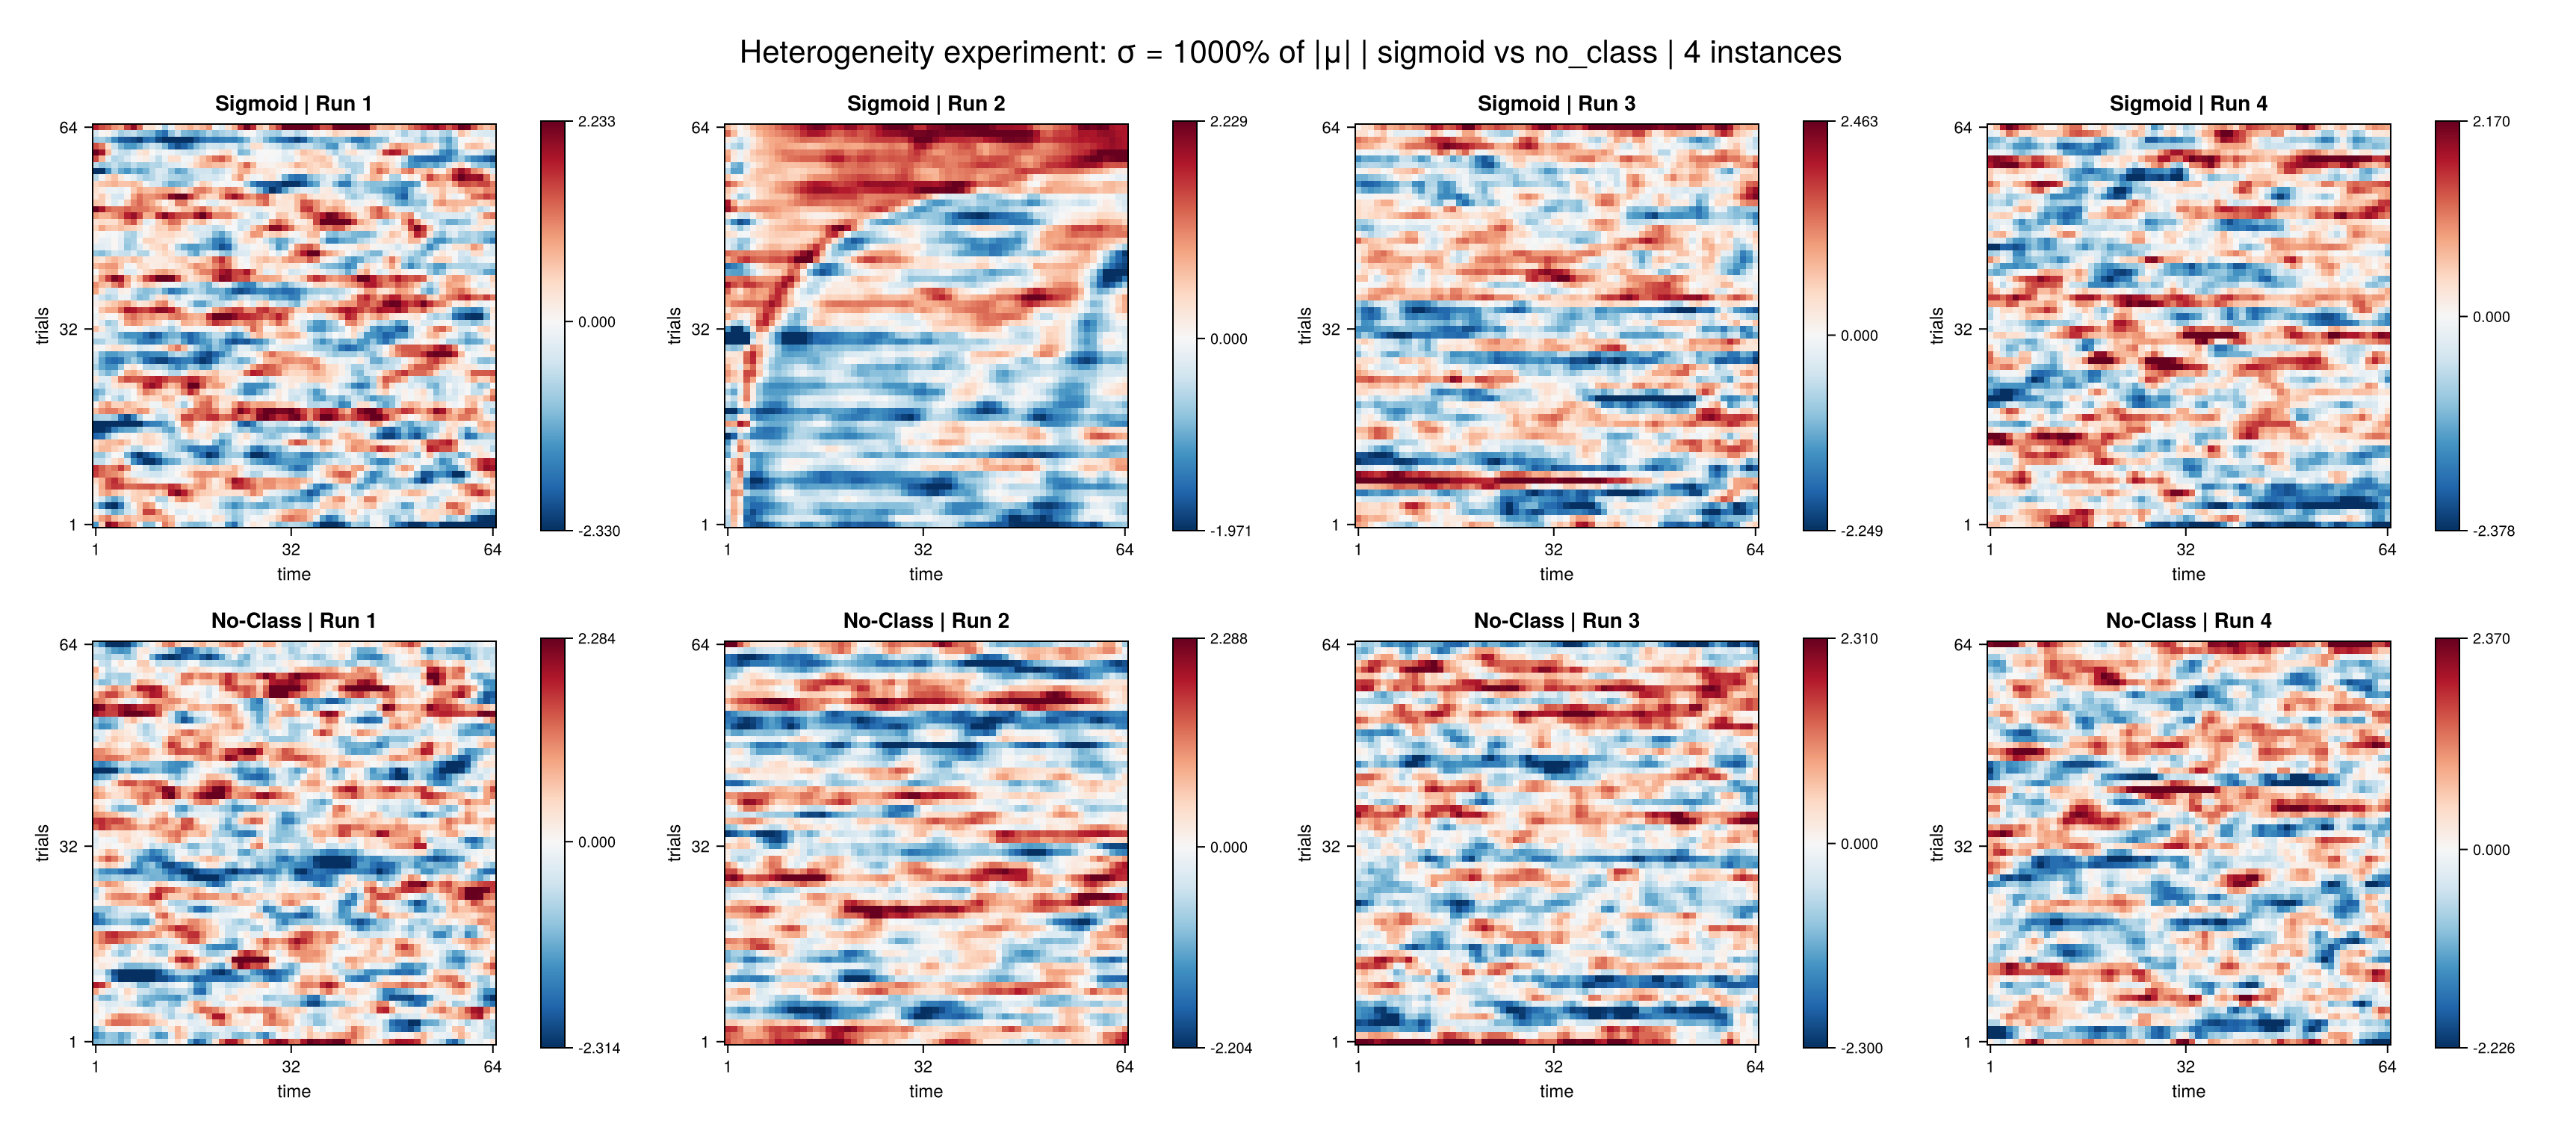

Dict{Symbol, NamedTuple} with 3 entries:
  :std_100pct  => (spec = (key = :std_100pct, ratio = 1.0, label = "σ = 100% of…
  :std_50pct   => (spec = (key = :std_50pct, ratio = 0.5, label = "σ = 50% of |…
  :std_1000pct => (spec = (key = :std_1000pct, ratio = 10.0, label = "σ = 1000%…

In [1]:
import Pkg
# Resolve the data_generation notebook directory and use absolute include paths.
data_gen_dir = if isfile(joinpath(pwd(), "erpgen.jl"))
    pwd()
else
    candidate = joinpath(pwd(), "notebooks", "data_generation")
    @assert isfile(joinpath(candidate, "erpgen.jl")) "Could not locate notebooks/data_generation/erpgen.jl from current working directory."
    candidate
end
cd(data_gen_dir)
Pkg.activate(data_gen_dir)
Pkg.instantiate()
if !isdefined(Main, :ERPGen)
    include(joinpath(data_gen_dir, "erpgen.jl"))
end
using .ERPGen
ERPGen.verify_unfoldsim_version!()
if !isdefined(Main, :ERPImageUtils)
    include(joinpath(data_gen_dir, "..", "utils", "erp_image_utils.jl"))
end
using .ERPImageUtils: clipped_color_stats_quantile_zero_ticks
import Random
import Distributions
using Distributions: Distribution, Normal, Uniform, truncated
using Interpolations
using CairoMakie
# -----------------------------
# Global experiment settings
# -----------------------------
base_seed = Int(mod(time_ns(), typemax(Int)))
n_instances = 4
q_low = 0.01
q_high = 0.99
std_specs = [
    (key = :std_50pct, ratio = 0.5, label = "σ = 50% of |μ|"),
    (key = :std_100pct, ratio = 1.0, label = "σ = 100% of |μ|"),
    (key = :std_1000pct, ratio = 10.0, label = "σ = 1000% of |μ|"),
]
real_n_trials = 2508
real_n_timepoints = 513
real_sampling_rate = 512
real_epoch_duration_s = (real_n_timepoints - 1) / real_sampling_rate
struct FixedDist <: Distribution{Distributions.Univariate, Distributions.Continuous}
    value::Float64
end
Random.rand(rng::Random.AbstractRNG, d::FixedDist) = d.value
Random.rand(d::FixedDist) = d.value
Distributions.mean(d::FixedDist) = d.value
Distributions.std(::FixedDist) = 0.0
fixed_dist(target::Real) = FixedDist(Float64(target))
# -----------------------------
# Utilities
# -----------------------------
# Scale std relative to mean magnitude; for near-zero means fallback to base std.
function s2r_scaled_std_from_mean(μ::Real, σ0::Real, ratio::Real)
    ref = abs(μ) > 1e-6 ? abs(μ) : abs(σ0)
    return max(1e-6, ref * ratio)
end
# Convert Normal(μ,σ0) -> truncated Normal(μ, σ_new) with optional bounds.
function s2r_scale_normal_dist(dist::Distribution, ratio::Real; lower::Float64 = -Inf, upper::Float64 = Inf)
    if dist isa Normal
        μ = Distributions.mean(dist)
        σ0 = Distributions.std(dist)
        σ_new = s2r_scaled_std_from_mean(μ, σ0, ratio)
        widened = Normal(μ, σ_new)
        if isfinite(lower) || isfinite(upper)
            return truncated(widened, lower, upper)
        end
        return widened
    end
    return dist
end
function s2r_make_heterogeneous_config(std_ratio::Float64)
    base = ERPGen.GenerationConfig()
    fixed_target_size = (base.processing.target_height, base.processing.target_width)
    sc(d; lo = -Inf, hi = Inf) = s2r_scale_normal_dist(d, std_ratio; lower = Float64(lo), upper = Float64(hi))
    # Keep simulation numerically stable while still broadening variance strongly.
    sim = ERPGen.SimulationConfig(
        mu_dist = sc(Normal(4.2, 0.3); lo = 0.2, hi = 12.0),
        sigma_dist = sc(base.sim.sigma_dist; lo = 0.01, hi = 3.0),
        epoch_duration_dist = fixed_dist(real_epoch_duration_s),
        sampling_rate_dist = fixed_dist(real_sampling_rate),
        n_trials_dist = fixed_dist(real_n_trials),
    )
    comp = ERPGen.ComponentConfig(
        p100_width_dist = sc(base.components.p100_width_dist; lo = 0.002, hi = 0.60),
        p100_window_offset_dist = sc(base.components.p100_window_offset_dist; lo = 0.005, hi = 1.20),
        p100_n170_gap_dist = sc(base.components.p100_n170_gap_dist; lo = 0.002, hi = 1.20),
        n170_p300_gap_dist = sc(base.components.n170_p300_gap_dist; lo = 0.002, hi = 1.20),
        n170_width_dist = sc(base.components.n170_width_dist; lo = 0.002, hi = 0.60),
        p300_width_dist = sc(base.components.p300_width_dist; lo = 0.002, hi = 0.80),
        p1_beta_dist = sc(base.components.p1_beta_dist; lo = -30.0, hi = 30.0),
        p3_beta_dist = sc(base.components.p3_beta_dist; lo = -30.0, hi = 30.0),
        n1_beta1_dist = sc(base.components.n1_beta1_dist; lo = -30.0, hi = 30.0),
        n1_beta2_dist = sc(base.components.n1_beta2_dist; lo = -30.0, hi = 30.0),
        n1_beta3_dist = sc(base.components.n1_beta3_dist; lo = -30.0, hi = 30.0),
        componentA_amp_dist = sc(base.components.componentA_amp_dist; lo = -30.0, hi = 30.0),
        componentB_amp_dist = sc(base.components.componentB_amp_dist; lo = -30.0, hi = 30.0),
        componentC_amp_dist = sc(base.components.componentC_amp_dist; lo = -30.0, hi = 30.0),
    )
    pat = ERPGen.PatternConfig(
        patterns = [:sigmoid],
        loaded_patterns = ERPGen.DEFAULT_PATTERN_LIST,
        covariate_dists = base.patterns.covariate_dists,
        diverging_bar_levels = base.patterns.diverging_bar_levels,
    )
    noiselevel_dists = Dict{DataType, Distribution}()
    for (k, d) in base.noise.noiselevel_dists
        noiselevel_dists[k] = sc(d; lo = 0.1, hi = 80.0)
    end
    noise = ERPGen.NoiseConfig(noise_pool = base.noise.noise_pool, noiselevel_dists = noiselevel_dists)
    proc = ERPGen.ProcessingConfig(
        dropout_trials_rate_dist = fixed_dist(0.0),
        crop_start_dist = fixed_dist(0.0),
        crop_end_dist = fixed_dist(0.0),
        zscore_timepoints = true,
        resize_antialias = true,
        low_pass_factor = base.processing.low_pass_factor,
        resize_method = base.processing.resize_method,
        target_height = fixed_target_size[1],
        target_width = fixed_target_size[2],
    )
    runtime = ERPGen.RuntimeConfig(
        threaded = false,
        show_progress = false,
        blas_threads = 1,
        progress_every = 20,
    )
    return ERPGen.GenerationConfig(
        sim = sim,
        components = comp,
        patterns = pat,
        noise = noise,
        processing = proc,
        runtime = runtime,
    )
end
function simulate_sigmoid_no_class_instance(config::ERPGen.GenerationConfig, rng::Random.AbstractRNG)
    raw = ERPGen.simulate_raw_erp(config, rng)
    data_fixed = raw.data
    events_fixed = raw.events
    sorted = ERPGen.sort_by_patterns(data_fixed, events_fixed, [:sigmoid, :no_class], rng)
    processed = ERPGen.process_images(sorted, config.processing)
    normalized = ERPGen.apply_zscore(processed.images, config.processing)
    return (
        sigmoid = normalized[:sigmoid],
        no_class = normalized[:no_class],
        raw_params = raw.params,
        raw_size = size(raw.data),
        fixed_size = size(data_fixed),
    )
end
function s2r_simulate_instances(config::ERPGen.GenerationConfig;
    n_instances::Int = 4,
    seed::Int = Int(mod(time_ns(), typemax(Int))),
    max_attempts::Int = 120)
    instances = NamedTuple[]
    attempts = 0
    failures = 0
    while length(instances) < n_instances && attempts < max_attempts
        attempts += 1
        rng = Random.Xoshiro(seed + 10_000 * attempts)
        try
            inst = simulate_sigmoid_no_class_instance(config, rng)
            push!(instances, inst)
        catch
            failures += 1
        end
    end
    @assert length(instances) == n_instances "Not enough successful simulations: $(length(instances))/$(n_instances)."
    return instances, failures
end
function axis_ticks(n::Int)
    mid = Int(cld(n, 2))
    vals = [1, mid, n]
    return vals, string.(vals)
end
function plot_sigmoid_vs_noclass(sigmoid_imgs::Vector{<:AbstractMatrix}, no_class_imgs::Vector{<:AbstractMatrix};
    title::String,
    q_low::Float64 = 0.01,
    q_high::Float64 = 0.99)
    n = min(length(sigmoid_imgs), length(no_class_imgs))
    n == 0 && error("No images to plot.")
    fig = Figure(size = (340 * n, 760), figure_padding = 22)
    Label(fig[0, 1:(2 * n)], title; fontsize = 21, tellwidth = false)
    rows = [
        (name = "Sigmoid", imgs = sigmoid_imgs),
        (name = "No-Class", imgs = no_class_imgs),
    ]
    for (row_i, row) in enumerate(rows)
        for run_i in 1:n
            img = Float32.(row.imgs[run_i])
            clipped, crange, tick_vals, tick_labels, cmap =
                clipped_color_stats_quantile_zero_ticks(img; q_low = q_low, q_high = q_high)
            xtick_vals, xtick_labels = axis_ticks(size(img, 2))
            ytick_vals, ytick_labels = axis_ticks(size(img, 1))
            img_col = 2 * run_i - 1
            cb_col = 2 * run_i
            ax = Axis(fig[row_i, img_col];
                title = "$(row.name) | Run $(run_i)",
                titlesize = 14,
                titlegap = 6,
                aspect = DataAspect(),
                xticks = (xtick_vals, xtick_labels),
                yticks = (ytick_vals, ytick_labels),
                xticklabelsize = 11,
                yticklabelsize = 11,
                xlabel = "time",
                ylabel = "trials",
                xlabelsize = 12,
                ylabelsize = 12,
            )
            hm = heatmap!(ax, permutedims(clipped, (2, 1)); colormap = cmap, colorrange = crange)
            Colorbar(fig[row_i, cb_col], hm; width = 16, ticklabelsize = 10, ticks = (tick_vals, tick_labels))
            colsize!(fig.layout, img_col, Fixed(270))
            colsize!(fig.layout, cb_col, Fixed(56))
        end
    end
    rowgap!(fig.layout, 12)
    colgap!(fig.layout, 10)
    resize_to_layout!(fig)
    return fig
end
function s2r_dist_stats(d::Distribution)
    μ = try
        Distributions.mean(d)
    catch
        NaN
    end
    σ = try
        Distributions.std(d)
    catch
        NaN
    end
    return (mean = μ, std = σ)
end
function s2r_fmt_num(x)
    if x isa Real && isfinite(x)
        return string(round(Float64(x); digits = 6))
    end
    return string(x)
end
function s2r_print_distribution_line(prefix::AbstractString, name::AbstractString, d::Distribution)
    st = s2r_dist_stats(d)
    println(prefix, name, " = ", d, " | mean=", s2r_fmt_num(st.mean), " std=", s2r_fmt_num(st.std))
end
function s2r_print_field(prefix::AbstractString, name::AbstractString, v)
    if v isa Distribution
        s2r_print_distribution_line(prefix, name, v)
    elseif v isa AbstractDict
        println(prefix, name, ":")
        for k in sort(collect(keys(v)); by = x -> string(x))
            kv = v[k]
            if kv isa Distribution
                s2r_print_distribution_line(prefix * "  ", string(k), kv)
            else
                println(prefix, "  ", k, " => ", kv)
            end
        end
    elseif v isa AbstractVector
        println(prefix, name, " = ", collect(v))
    else
        println(prefix, name, " = ", v)
    end
end
function s2r_print_section(title::String, cfg_obj)
    println(title)
    for fn in fieldnames(typeof(cfg_obj))
        s2r_print_field("  ", string(fn), getfield(cfg_obj, fn))
    end
end
function s2r_print_full_config(cfg::ERPGen.GenerationConfig, label::String)
    println("\n=== Full parameter settings | ", label, " ===")
    s2r_print_section("[SimulationConfig]", cfg.sim)
    s2r_print_section("[ComponentConfig]", cfg.components)
    s2r_print_section("[PatternConfig]", cfg.patterns)
    s2r_print_section("[NoiseConfig]", cfg.noise)
    s2r_print_section("[ProcessingConfig]", cfg.processing)
    s2r_print_section("[RuntimeConfig]", cfg.runtime)
end
function s2r_print_config_snapshot(cfg::ERPGen.GenerationConfig, label::String)
    println("\n=== $(label) ===")
    sim_mu = s2r_dist_stats(cfg.sim.mu_dist)
    sim_sigma = s2r_dist_stats(cfg.sim.sigma_dist)
    sim_epoch = s2r_dist_stats(cfg.sim.epoch_duration_dist)
    sim_sr = s2r_dist_stats(cfg.sim.sampling_rate_dist)
    println("sim.mu_dist: mean=", round(sim_mu.mean; digits = 4), " std=", round(sim_mu.std; digits = 4))
    println("sim.sigma_dist: mean=", round(sim_sigma.mean; digits = 4), " std=", round(sim_sigma.std; digits = 4))
    println("sim.epoch_duration_dist: mean=", round(sim_epoch.mean; digits = 4), " std=", round(sim_epoch.std; digits = 4))
    println("sim.sampling_rate_dist: mean=", round(sim_sr.mean; digits = 4), " std=", round(sim_sr.std; digits = 4))
    p100w = s2r_dist_stats(cfg.components.p100_width_dist)
    n170w = s2r_dist_stats(cfg.components.n170_width_dist)
    p300w = s2r_dist_stats(cfg.components.p300_width_dist)
    println("component widths: p100 std=", round(p100w.std; digits = 5),
        " | n170 std=", round(n170w.std; digits = 5),
        " | p300 std=", round(p300w.std; digits = 5))
end
# -----------------------------
# Run the 3 heterogeneity attempts
# -----------------------------
results = Dict{Symbol, NamedTuple}()
for (idx, spec) in enumerate(std_specs)
    cfg = s2r_make_heterogeneous_config(spec.ratio)
    s2r_print_full_config(cfg, spec.label)
    instances, failures = s2r_simulate_instances(cfg;
        n_instances = n_instances,
        seed = base_seed + idx * 1_000_000,
        max_attempts = 200)
    sigmoid_images = [inst.sigmoid for inst in instances]
    no_class_images = [inst.no_class for inst in instances]
    println("successful instances: ", length(instances), " / ", n_instances, " | failed attempts skipped: ", failures)
    for (run_i, inst) in enumerate(instances)
        println("  run ", run_i,
            " | sr=", inst.raw_params.sampling_rate,
            "Hz | epoch=", round(inst.raw_params.epoch_duration_s; digits = 3), "s",
            " | raw_size=", inst.raw_size,
            " | fixed_size=", inst.fixed_size)
    end
    fig = plot_sigmoid_vs_noclass(sigmoid_images, no_class_images;
        title = "Heterogeneity experiment: $(spec.label) | sigmoid vs no_class | 4 instances",
        q_low = q_low,
        q_high = q_high)
    display(fig)
    results[spec.key] = (
        spec = spec,
        config = cfg,
        instances = instances,
        failures = failures,
        figure = fig,
    )
end
results
